# Asset Impact Analysis

**Business question:** which NVIDIA assets drive meaningful engagement?

This notebook uses the feature engineering outputs and GMM cluster assignments already written to `developer_project.duckdb` to evaluate how trainings, webinars, downloads, SDK activity, forums, and APIs relate to deeper developer engagement.

The notebook is intentionally aggregation-first: it creates compact DuckDB report tables, then pulls only summary tables into pandas for display and plotting.


## Method Summary

The analysis is observational, not causal. It compares developer behavior before and after a developer's first observed touch of each asset type.

Primary window:

- **Pre period:** 90 days before first asset touch.
- **Post period:** 90 days after first asset touch.
- **Asset day:** excluded from pre/post deltas to avoid mechanically counting the triggering touch as uplift.

Meaningful adoption is separated from shallow engagement using build/champion signals, high effort rank, API/cloud workspace use, forum contribution, SDK download behavior, and retained activity 31-90 days after the first touch.


In [1]:
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

DB_PATH = Path('developer_project.duckdb')
OUTPUT_DIR = Path('asset_impact_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

PRE_DAYS = 90
POST_DAYS = 90
PRE_WEEKS = 8
POST_WEEKS = 8

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')

con = duckdb.connect(str(DB_PATH), read_only=False)
con.execute("SET preserve_insertion_order=false")
con.execute("SET threads=4")

print(f'DuckDB path: {DB_PATH.resolve()} exists={DB_PATH.exists()}')
print(f'Output directory: {OUTPUT_DIR.resolve()}')


DuckDB path: /Users/shanewaldron/Desktop/MSBA/NVIDIA/Spring2026_IndustryProject/developer_project.duckdb exists=True
Output directory: /Users/shanewaldron/Desktop/MSBA/NVIDIA/Spring2026_IndustryProject/asset_impact_outputs


In [2]:
tables_df = con.execute('SHOW TABLES').fetchdf()
table_col = tables_df.columns[0]
available_tables = set(tables_df[table_col].astype(str))

required_tables = {
    'activity_labeled_v2',
    'dev_profile_final_v4',
    'dev_gmm_clusters_v1',
}
missing = sorted(required_tables - available_tables)
if missing:
    raise RuntimeError(
        'Missing required table(s): ' + ', '.join(missing) +
        '. Run FeatureEngineering_v3.ipynb and GMM_Cluster.ipynb before this notebook.'
    )

has_weekly_gmm = 'dev_gmm_weekly_clusters_v1' in available_tables
sdk_table = next((t for t in ['sdk_download_final', 'sdk_download_clean'] if t in available_tables), None)

status = pd.DataFrame([
    {'dependency': 'activity_labeled_v2', 'available': 'activity_labeled_v2' in available_tables, 'purpose': 'row-level activity and asset touchpoints'},
    {'dependency': 'dev_profile_final_v4', 'available': 'dev_profile_final_v4' in available_tables, 'purpose': 'developer-level engagement profile'},
    {'dependency': 'dev_gmm_clusters_v1', 'available': 'dev_gmm_clusters_v1' in available_tables, 'purpose': 'developer-level GMM cohort assignment'},
    {'dependency': 'dev_gmm_weekly_clusters_v1', 'available': has_weekly_gmm, 'purpose': 'weekly cohort movement, optional'},
    {'dependency': 'sdk_download_final / sdk_download_clean', 'available': sdk_table is not None, 'purpose': 'global SDK product download analysis, optional'},
])
display(status)


,dependency,available,purpose
0,activity_labeled_v2,True,row-level activity and asset touchpoints
1,dev_profile_final_v4,True,developer-level engagement profile
2,dev_gmm_clusters_v1,True,developer-level GMM cohort assignment
3,dev_gmm_weekly_clusters_v1,True,"weekly cohort movement, optional"
4,sdk_download_final / sdk_download_clean,True,"global SDK product download analysis, optional"


In [3]:
activity_cols = set(con.execute("PRAGMA table_info('activity_labeled_v2')").fetchdf()['name'])
cluster_cols = set(con.execute("PRAGMA table_info('dev_gmm_clusters_v1')").fetchdf()['name'])

required_activity_cols = {
    'developer_id', 'activity_date', 'activity', 'activity_score', 'journey_signal',
    'effort_rank', 'modality'
}
missing_activity_cols = sorted(required_activity_cols - activity_cols)
if missing_activity_cols:
    raise RuntimeError(f'activity_labeled_v2 is missing required columns: {missing_activity_cols}')

required_cluster_cols = {'developer_id', 'gmm_cluster_id', 'gmm_cluster_label'}
missing_cluster_cols = sorted(required_cluster_cols - cluster_cols)
if missing_cluster_cols:
    raise RuntimeError(f'dev_gmm_clusters_v1 is missing required columns: {missing_cluster_cols}')

print('Schema checks passed.')


Schema checks passed.


## 1. Asset Definitions

Each row in `activity_labeled_v2` is mapped into one of six asset families:

- `training`: DLI training.
- `webinar`: webinars, on-demand views, and live conference sessions.
- `sdk_download`: SDK download activity.
- `download`: DevZone, NGC, and other non-SDK download activity.
- `forum`: forum contribution activity.
- `api`: hosted/model API activity.

The order matters: SDK downloads are classified before the broader download bucket.


In [4]:
ASSET_CASE = """
CASE
    WHEN activity = 'dli training' THEN 'training'
    WHEN activity IN ('webinars', 'on-demand views', 'conf. sessions live') THEN 'webinar'
    WHEN activity = 'sdk downloads' THEN 'sdk_download'
    WHEN activity IN ('devzone downloads', 'ngc downloads') OR modality = 'Download' THEN 'download'
    WHEN activity = 'forum contributions' THEN 'forum'
    WHEN activity IN ('hosted api', 'model api') OR modality = 'Hosted API' THEN 'api'
    ELSE NULL
END
"""

con.execute(f"""
CREATE OR REPLACE TABLE asset_first_touch_v1 AS
WITH asset_rows AS (
    SELECT
        developer_id,
        {ASSET_CASE} AS asset_type,
        activity_date,
        COALESCE(activity_score, 0) AS activity_score,
        CASE WHEN journey_signal = 'Build' THEN 1 ELSE 0 END AS build_flag,
        CASE WHEN journey_signal = 'Champion' THEN 1 ELSE 0 END AS champion_flag,
        CASE WHEN effort_rank >= 3 THEN 1 ELSE 0 END AS high_effort_flag
    FROM activity_labeled_v2
    WHERE developer_id IS NOT NULL
      AND activity_date IS NOT NULL
)
SELECT
    developer_id,
    asset_type,
    MIN(activity_date) AS first_asset_date,
    COUNT(*) AS lifetime_asset_events,
    SUM(activity_score) AS lifetime_asset_score,
    SUM(build_flag) AS lifetime_asset_build_events,
    SUM(champion_flag) AS lifetime_asset_champion_events,
    SUM(high_effort_flag) AS lifetime_asset_high_effort_events
FROM asset_rows
WHERE asset_type IS NOT NULL
GROUP BY 1, 2
""")

asset_first_touch = con.execute("""
SELECT
    asset_type,
    COUNT(*) AS touched_developers,
    SUM(lifetime_asset_events) AS asset_events,
    ROUND(AVG(lifetime_asset_events), 2) AS avg_events_per_touched_developer,
    MIN(first_asset_date) AS first_observed_touch,
    MAX(first_asset_date) AS last_observed_touch
FROM asset_first_touch_v1
GROUP BY 1
ORDER BY touched_developers DESC
""").fetchdf()

display(asset_first_touch)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,asset_type,touched_developers,asset_events,avg_events_per_touched_developer,first_observed_touch,last_observed_touch
0,download,4036045,47459675.0,11.76,2020-01-01,2026-03-12
1,training,1077540,1709244.0,1.59,2020-01-01,2026-03-12
2,webinar,692412,3059541.0,4.42,2020-01-01,2026-03-12
3,api,266143,6466203.0,24.30,2024-03-20,2026-03-12
4,forum,17402,93535.0,5.37,2020-01-01,2026-03-08


## 2. Pre/Post Engagement Windows

The next table is the core impact table. It contains one row per `developer_id` and `asset_type` based on the developer's first touch of that asset family.

Metrics include total engagement, score, build/champion activity, high-effort activity, meaningful adoption, and retention activity 31-90 days after the first touch.


In [5]:
STAGE_RANK_A = """
CASE
    WHEN a.journey_signal = 'Discover' THEN 1
    WHEN a.journey_signal = 'Learn' THEN 2
    WHEN a.journey_signal = 'Evaluate' THEN 3
    WHEN a.journey_signal = 'Build' THEN 4
    WHEN a.journey_signal = 'Champion' THEN 5
    ELSE 0
END
"""

MEANINGFUL_A = """
CASE
    WHEN a.journey_signal IN ('Build', 'Champion')
      OR COALESCE(a.effort_rank, 0) >= 3
      OR a.modality IN ('Hosted API', 'Cloud Workspace', 'Community')
      OR a.activity IN ('forum contributions', 'hosted api', 'model api', 'sdk downloads')
    THEN 1 ELSE 0
END
"""

con.execute(f"""
CREATE OR REPLACE TABLE asset_pre_post_developer_v1 AS
WITH metrics AS (
    SELECT
        t.developer_id,
        t.asset_type,
        t.first_asset_date,
        t.lifetime_asset_events,
        t.lifetime_asset_score,

        COALESCE(SUM(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date THEN 1 ELSE 0 END), 0) AS pre_activity_count,
        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY THEN 1 ELSE 0 END), 0) AS post_activity_count,

        COALESCE(SUM(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date THEN COALESCE(a.activity_score, 0) ELSE 0 END), 0) AS pre_activity_score_sum,
        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY THEN COALESCE(a.activity_score, 0) ELSE 0 END), 0) AS post_activity_score_sum,

        COALESCE(SUM(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date AND a.journey_signal = 'Build' THEN 1 ELSE 0 END), 0) AS pre_build_count,
        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY AND a.journey_signal = 'Build' THEN 1 ELSE 0 END), 0) AS post_build_count,

        COALESCE(SUM(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date AND a.journey_signal = 'Champion' THEN 1 ELSE 0 END), 0) AS pre_champion_count,
        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY AND a.journey_signal = 'Champion' THEN 1 ELSE 0 END), 0) AS post_champion_count,

        COALESCE(SUM(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date AND COALESCE(a.effort_rank, 0) >= 3 THEN 1 ELSE 0 END), 0) AS pre_high_effort_count,
        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY AND COALESCE(a.effort_rank, 0) >= 3 THEN 1 ELSE 0 END), 0) AS post_high_effort_count,

        COALESCE(SUM(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date THEN {MEANINGFUL_A} ELSE 0 END), 0) AS pre_meaningful_count,
        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY THEN {MEANINGFUL_A} ELSE 0 END), 0) AS post_meaningful_count,

        COALESCE(SUM(CASE WHEN a.activity_date >  t.first_asset_date + INTERVAL 30 DAY
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY THEN 1 ELSE 0 END), 0) AS post_31_90_activity_count,

        COALESCE(MAX(CASE WHEN a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
                           AND a.activity_date <  t.first_asset_date THEN {STAGE_RANK_A} ELSE 0 END), 0) AS pre_max_stage_rank,
        COALESCE(MAX(CASE WHEN a.activity_date >  t.first_asset_date
                           AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY THEN {STAGE_RANK_A} ELSE 0 END), 0) AS post_max_stage_rank
    FROM asset_first_touch_v1 t
    LEFT JOIN activity_labeled_v2 a
      ON a.developer_id = t.developer_id
     AND a.activity_date >= t.first_asset_date - INTERVAL {PRE_DAYS} DAY
     AND a.activity_date <= t.first_asset_date + INTERVAL {POST_DAYS} DAY
     AND a.activity_date <> t.first_asset_date
    GROUP BY 1, 2, 3, 4, 5
)
SELECT
    *,
    post_activity_count - pre_activity_count AS activity_count_delta,
    post_activity_score_sum - pre_activity_score_sum AS activity_score_delta,
    post_build_count - pre_build_count AS build_count_delta,
    post_champion_count - pre_champion_count AS champion_count_delta,
    post_high_effort_count - pre_high_effort_count AS high_effort_count_delta,
    post_meaningful_count - pre_meaningful_count AS meaningful_count_delta,
    post_max_stage_rank - pre_max_stage_rank AS stage_rank_delta,
    CASE WHEN post_max_stage_rank > pre_max_stage_rank THEN 1 ELSE 0 END AS progressed_stage_flag,
    CASE WHEN post_build_count + post_champion_count > 0 THEN 1 ELSE 0 END AS post_build_or_champion_flag,
    CASE WHEN post_31_90_activity_count > 0 THEN 1 ELSE 0 END AS retained_31_90d_flag,
    CASE
        WHEN post_meaningful_count = 0
         AND post_build_count = 0
         AND post_high_effort_count = 0
         AND post_activity_count <= pre_activity_count
        THEN 1 ELSE 0
    END AS shallow_no_lift_flag
FROM metrics
""")

preview = con.execute("""
SELECT *
FROM asset_pre_post_developer_v1
ORDER BY asset_type, first_asset_date
LIMIT 10
""").fetchdf()
display(preview)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,developer_id,asset_type,first_asset_date,lifetime_asset_events,lifetime_asset_score,pre_activity_count,post_activity_count,pre_activity_score_sum,post_activity_score_sum,pre_build_count,post_build_count,pre_champion_count,post_champion_count,pre_high_effort_count,post_high_effort_count,pre_meaningful_count,post_meaningful_count,post_31_90_activity_count,pre_max_stage_rank,post_max_stage_rank,activity_count_delta,activity_score_delta,build_count_delta,champion_count_delta,high_effort_count_delta,meaningful_count_delta,stage_rank_delta,progressed_stage_flag,post_build_or_champion_flag,retained_31_90d_flag,shallow_no_lift_flag
0,6226336,api,2024-03-20,25,0.0,3.0,20.0,18.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0,20.0,1.0,4,1,17.0,-18.0,-3.0,0.0,-3.0,17.0,-3,0,0,1,0
1,6353078,api,2024-03-20,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1
2,6280098,api,2024-03-20,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1
3,5939769,api,2024-03-20,111,0.0,68.0,66.0,388.0,133.0,68.0,16.0,0.0,12.0,67.0,28.0,68.0,66.0,44.0,4,5,-2.0,-255.0,-52.0,12.0,-39.0,-2.0,1,1,1,1,0
4,6250838,api,2024-03-20,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1
5,6201208,api,2024-03-21,119,0.0,0.0,48.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,48.0,34.0,0,1,48.0,0.0,0.0,0.0,0.0,48.0,1,1,0,1,0
6,6369085,api,2024-03-21,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1
7,6535308,api,2024-03-21,3,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0,1,2.0,0.0,0.0,0.0,0.0,2.0,1,1,0,0,0
8,6375324,api,2024-03-21,7,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,1,4.0,0.0,0.0,0.0,0.0,4.0,1,1,0,0,0
9,6372228,api,2024-03-21,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,1,1,0,0,0


In [6]:
con.execute("""
CREATE OR REPLACE TABLE asset_pre_post_summary_v1 AS
SELECT
    asset_type,
    COUNT(*) AS touched_developers,
    ROUND(AVG(lifetime_asset_events), 2) AS avg_lifetime_asset_events,
    ROUND(AVG(pre_activity_count), 2) AS avg_pre_activity_count,
    ROUND(AVG(post_activity_count), 2) AS avg_post_activity_count,
    ROUND(AVG(activity_count_delta), 2) AS avg_activity_count_delta,
    MEDIAN(activity_count_delta) AS median_activity_count_delta,
    ROUND(AVG(pre_activity_score_sum), 2) AS avg_pre_activity_score_sum,
    ROUND(AVG(post_activity_score_sum), 2) AS avg_post_activity_score_sum,
    ROUND(AVG(activity_score_delta), 2) AS avg_activity_score_delta,
    ROUND(AVG(build_count_delta), 3) AS avg_build_count_delta,
    ROUND(AVG(high_effort_count_delta), 3) AS avg_high_effort_count_delta,
    ROUND(AVG(meaningful_count_delta), 3) AS avg_meaningful_count_delta,
    ROUND(AVG(progressed_stage_flag), 4) AS progressed_stage_rate,
    ROUND(AVG(post_build_or_champion_flag), 4) AS post_build_or_champion_rate,
    ROUND(AVG(retained_31_90d_flag), 4) AS retained_31_90d_rate,
    ROUND(AVG(shallow_no_lift_flag), 4) AS shallow_no_lift_rate
FROM asset_pre_post_developer_v1
GROUP BY 1
ORDER BY avg_meaningful_count_delta DESC, progressed_stage_rate DESC
""")

asset_summary = con.execute("SELECT * FROM asset_pre_post_summary_v1").fetchdf()
display(asset_summary)


,asset_type,touched_developers,avg_lifetime_asset_events,avg_pre_activity_count,avg_post_activity_count,avg_activity_count_delta,median_activity_count_delta,avg_pre_activity_score_sum,avg_post_activity_score_sum,avg_activity_score_delta,avg_build_count_delta,avg_high_effort_count_delta,avg_meaningful_count_delta,progressed_stage_rate,post_build_or_champion_rate,retained_31_90d_rate,shallow_no_lift_rate
0,api,266143,24.30,1.07,14.70,13.63,2.0,4.21,4.59,0.38,0.256,0.040,13.674,0.5222,0.0288,0.2217,0.3198
1,download,4036045,11.76,0.09,3.04,2.95,0.0,0.53,9.23,8.69,2.202,0.121,2.212,0.2802,0.1804,0.1012,0.7206
2,training,1077540,1.59,0.79,1.25,0.46,0.0,2.48,9.46,6.98,0.156,0.004,0.164,0.1536,0.0309,0.0701,0.8370
3,webinar,692412,4.42,1.59,2.81,1.22,0.0,7.07,15.61,8.55,0.056,-0.290,-0.271,0.2925,0.0447,0.0872,0.7058
4,forum,17402,5.37,18.82,14.50,-4.32,0.0,54.81,39.19,-15.61,-4.653,-0.395,-3.238,0.4301,0.4818,0.3243,0.4495


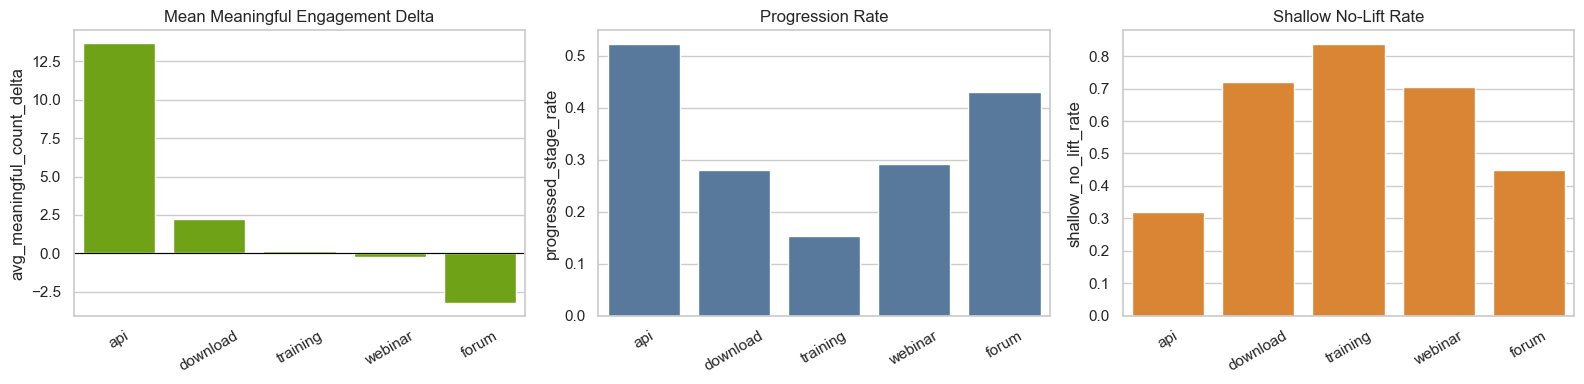

In [7]:
if not asset_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    sns.barplot(data=asset_summary, x='asset_type', y='avg_meaningful_count_delta', ax=axes[0], color='#76b900')
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title('Mean Meaningful Engagement Delta')
    axes[0].set_xlabel('')
    axes[0].tick_params(axis='x', rotation=30)

    sns.barplot(data=asset_summary, x='asset_type', y='progressed_stage_rate', ax=axes[1], color='#4c78a8')
    axes[1].set_title('Progression Rate')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=30)

    sns.barplot(data=asset_summary, x='asset_type', y='shallow_no_lift_rate', ax=axes[2], color='#f58518')
    axes[2].set_title('Shallow No-Lift Rate')
    axes[2].set_xlabel('')
    axes[2].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
else:
    display(Markdown('No asset summary rows were produced.'))


## 3. Asset-to-GMM Cohort Findings

This section asks whether specific assets concentrate in specific developer clusters and whether the post-asset uplift differs by cluster. High touch rates in low-adoption clusters may indicate awareness assets; high uplift in build-heavy clusters may indicate adoption assets.


In [8]:
con.execute("""
CREATE OR REPLACE TABLE asset_cluster_profile_v1 AS
WITH cluster_population AS (
    SELECT
        gmm_cluster_id,
        gmm_cluster_label,
        COUNT(*) AS cluster_developers
    FROM dev_gmm_clusters_v1
    GROUP BY 1, 2
),
asset_cluster AS (
    SELECT
        p.asset_type,
        c.gmm_cluster_id,
        c.gmm_cluster_label,
        COUNT(*) AS touched_developers,
        ROUND(AVG(p.activity_count_delta), 2) AS avg_activity_count_delta,
        ROUND(AVG(p.meaningful_count_delta), 2) AS avg_meaningful_count_delta,
        ROUND(AVG(p.build_count_delta), 3) AS avg_build_count_delta,
        ROUND(AVG(p.progressed_stage_flag), 4) AS progressed_stage_rate,
        ROUND(AVG(p.post_build_or_champion_flag), 4) AS post_build_or_champion_rate,
        ROUND(AVG(p.retained_31_90d_flag), 4) AS retained_31_90d_rate,
        ROUND(AVG(p.shallow_no_lift_flag), 4) AS shallow_no_lift_rate
    FROM asset_pre_post_developer_v1 p
    JOIN dev_gmm_clusters_v1 c USING (developer_id)
    GROUP BY 1, 2, 3
)
SELECT
    a.*,
    cp.cluster_developers,
    ROUND(a.touched_developers * 1.0 / NULLIF(cp.cluster_developers, 0), 5) AS touch_rate_in_cluster,
    ROUND(a.touched_developers * 1.0 / NULLIF(SUM(a.touched_developers) OVER (PARTITION BY a.asset_type), 0), 5) AS asset_touch_share
FROM asset_cluster a
JOIN cluster_population cp USING (gmm_cluster_id, gmm_cluster_label)
ORDER BY asset_type, touch_rate_in_cluster DESC
""")

cluster_profile = con.execute("SELECT * FROM asset_cluster_profile_v1").fetchdf()
display(cluster_profile.head(30))


,asset_type,gmm_cluster_id,gmm_cluster_label,touched_developers,avg_activity_count_delta,avg_meaningful_count_delta,avg_build_count_delta,progressed_stage_rate,post_build_or_champion_rate,retained_31_90d_rate,shallow_no_lift_rate,cluster_developers,touch_rate_in_cluster,asset_touch_share
0,api,1,cluster_1,90290,25.57,25.61,-0.028,0.5982,0.0188,0.4272,0.1796,259172,0.34838,0.33925
1,api,5,cluster_5,158154,3.59,3.59,0.000,0.4862,0.0000,0.0759,0.4101,545512,0.28992,0.59424
2,api,4,cluster_4,17699,42.41,42.88,4.000,0.4558,0.3367,0.4766,0.2290,88507,0.19997,0.06650
3,download,3,cluster_3,2181522,2.91,2.07,2.083,0.3920,0.2493,0.1239,0.6094,2241081,0.97342,0.54051
4,download,4,cluster_4,66910,31.79,25.99,24.733,0.7173,0.5556,0.5320,0.2562,88507,0.75599,0.01658
5,download,1,cluster_1,143275,19.72,15.99,15.877,0.5099,0.3642,0.2445,0.4890,259172,0.55282,0.03550
6,download,0,cluster_0,1252264,-0.01,-0.01,0.000,0.0000,0.0000,0.0000,1.0000,2814423,0.44495,0.31027
7,download,2,cluster_2,372012,1.60,1.02,1.104,0.4133,0.2529,0.1812,0.5918,1705732,0.21810,0.09217
8,download,5,cluster_5,20062,0.05,0.05,0.047,0.0472,0.0472,0.0055,0.9528,545512,0.03678,0.00497
9,forum,4,cluster_4,17402,-4.32,-3.24,-4.653,0.4301,0.4818,0.3243,0.4495,88507,0.19662,1.00000


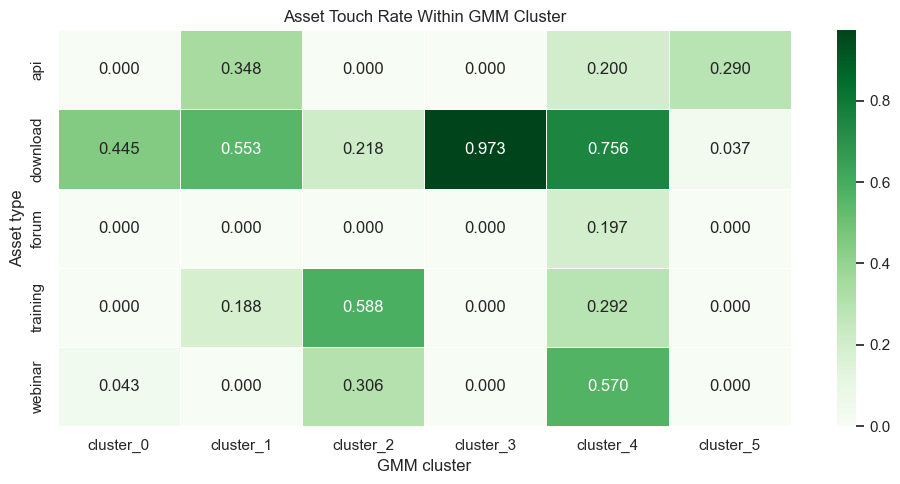

In [9]:
if not cluster_profile.empty:
    heat = cluster_profile.pivot_table(
        index='asset_type',
        columns='gmm_cluster_label',
        values='touch_rate_in_cluster',
        aggfunc='mean',
    ).fillna(0)

    plt.figure(figsize=(max(10, heat.shape[1] * 1.2), 5))
    sns.heatmap(heat, cmap='Greens', annot=True, fmt='.3f', linewidths=0.4)
    plt.title('Asset Touch Rate Within GMM Cluster')
    plt.xlabel('GMM cluster')
    plt.ylabel('Asset type')
    plt.tight_layout()
    plt.show()
else:
    display(Markdown('No cluster profile rows were produced.'))


## 4. Weekly Cluster Movement

If `dev_gmm_weekly_clusters_v1` exists, the notebook compares the modal weekly cluster before and after the first asset touch. This helps connect assets to cohort movement, not just one-time activity deltas.


In [10]:
if has_weekly_gmm:
    con.execute(f"""
    CREATE OR REPLACE TABLE asset_weekly_cluster_movement_v1 AS
    WITH weekly_counts AS (
        SELECT
            t.developer_id,
            t.asset_type,
            CASE
                WHEN w.week_start < DATE_TRUNC('week', t.first_asset_date) THEN 'pre'
                WHEN w.week_start > DATE_TRUNC('week', t.first_asset_date) THEN 'post'
                ELSE 'asset_week'
            END AS period,
            w.gmm_weekly_cluster_id,
            COUNT(*) AS n_weeks
        FROM asset_first_touch_v1 t
        JOIN dev_gmm_weekly_clusters_v1 w
          ON w.developer_id = t.developer_id
         AND w.week_start >= DATE_TRUNC('week', t.first_asset_date) - INTERVAL {PRE_WEEKS} WEEK
         AND w.week_start <= DATE_TRUNC('week', t.first_asset_date) + INTERVAL {POST_WEEKS} WEEK
        WHERE w.week_start <> DATE_TRUNC('week', t.first_asset_date)
        GROUP BY 1, 2, 3, 4
    ),
    modal AS (
        SELECT * EXCLUDE (rn)
        FROM (
            SELECT
                *,
                ROW_NUMBER() OVER (
                    PARTITION BY developer_id, asset_type, period
                    ORDER BY n_weeks DESC, gmm_weekly_cluster_id
                ) AS rn
            FROM weekly_counts
            WHERE period IN ('pre', 'post')
        ) x
        WHERE rn = 1
    ),
    wide AS (
        SELECT
            developer_id,
            asset_type,
            MAX(CASE WHEN period = 'pre' THEN gmm_weekly_cluster_id END) AS pre_weekly_cluster_id,
            MAX(CASE WHEN period = 'post' THEN gmm_weekly_cluster_id END) AS post_weekly_cluster_id,
            MAX(CASE WHEN period = 'pre' THEN n_weeks END) AS pre_cluster_weeks,
            MAX(CASE WHEN period = 'post' THEN n_weeks END) AS post_cluster_weeks
        FROM modal
        GROUP BY 1, 2
    )
    SELECT
        *,
        CASE
            WHEN pre_weekly_cluster_id IS NULL OR post_weekly_cluster_id IS NULL THEN 'insufficient_weekly_history'
            WHEN pre_weekly_cluster_id = post_weekly_cluster_id THEN 'stayed_same_weekly_cluster'
            ELSE 'changed_weekly_cluster'
        END AS weekly_cluster_movement,
        CASE WHEN pre_weekly_cluster_id IS NOT NULL
               AND post_weekly_cluster_id IS NOT NULL
               AND pre_weekly_cluster_id <> post_weekly_cluster_id
             THEN 1 ELSE 0 END AS changed_weekly_cluster_flag
    FROM wide
    """)

    con.execute("""
    CREATE OR REPLACE TABLE asset_weekly_cluster_movement_summary_v1 AS
    SELECT
        asset_type,
        pre_weekly_cluster_id,
        post_weekly_cluster_id,
        weekly_cluster_movement,
        COUNT(*) AS developers,
        ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY asset_type), 5) AS transition_share
    FROM asset_weekly_cluster_movement_v1
    GROUP BY 1, 2, 3, 4
    ORDER BY asset_type, developers DESC
    """)

    weekly_movement = con.execute("SELECT * FROM asset_weekly_cluster_movement_summary_v1").fetchdf()
    display(weekly_movement.head(50))
else:
    display(Markdown('`dev_gmm_weekly_clusters_v1` was not found. Weekly cluster movement was skipped. Run the weekly section of `GMM_Cluster.ipynb` to enable it.'))


,asset_type,pre_weekly_cluster_id,post_weekly_cluster_id,weekly_cluster_movement,developers,transition_share
0,api,<NA>,2,insufficient_weekly_history,123234,0.76717
1,api,0,2,changed_weekly_cluster,13900,0.08653
2,api,0,<NA>,insufficient_weekly_history,10440,0.06499
3,api,2,2,stayed_same_weekly_cluster,2238,0.01393
4,api,2,<NA>,insufficient_weekly_history,1726,0.01074
5,api,<NA>,0,insufficient_weekly_history,1632,0.01016
6,api,3,2,changed_weekly_cluster,1526,0.00950
7,api,3,<NA>,insufficient_weekly_history,1426,0.00888
8,api,<NA>,3,insufficient_weekly_history,1235,0.00769
9,api,0,0,stayed_same_weekly_cluster,805,0.00501


## 5. SDK Download Insights

Developer-level SDK impact is measured through `activity_labeled_v2` via the `sdk_download` asset type. The raw SDK download table is product-level. If it is not developer-linked, it should be used for asset demand and product mix, not user-level attribution.


Using SDK table: sdk_download_final
No developer-link column found in the SDK table. SDK product insights below are global demand signals, not developer-level attribution.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,sdk_name,product_name,product_release,rows,total_downloads,first_download_date,last_download_date,countries,operating_systems
0,cudnn,nvidia-cudnn-cu12,9.1.0.70,139833,207147890.0,2024-04-22,2026-03-09,228,6
1,cublas,nvidia-cublas-cu12,12.1.3.1,203816,206975743.0,2023-04-19,2026-03-09,229,11
2,cufft,nvidia-cufft-cu12,11.0.2.54,198378,204675094.0,2023-04-19,2026-03-09,229,11
3,nvrtc,nvidia-cuda-nvrtc-cu12,12.1.105,199833,204281843.0,2023-04-19,2026-03-09,229,11
4,curand,nvidia-curand-cu12,10.3.2.106,196950,204089884.0,2023-04-19,2026-03-09,229,11
5,cupti,nvidia-cuda-cupti-cu12,12.1.105,200899,203940476.0,2023-04-19,2026-03-09,229,11
6,cuda toolkit,nvidia-cuda-runtime-cu12,12.1.105,204055,202151753.0,2023-04-19,2026-03-09,229,11
7,cusparse,nvidia-cusparse-cu12,12.1.0.106,171259,202055117.0,2023-04-19,2026-03-09,228,6
8,cusolver,nvidia-cusolver-cu12,11.4.5.107,171140,201581959.0,2023-04-19,2026-03-09,228,6
9,nvtx,nvidia-nvtx-cu12,12.1.105,194708,199930196.0,2023-04-19,2026-03-09,229,12


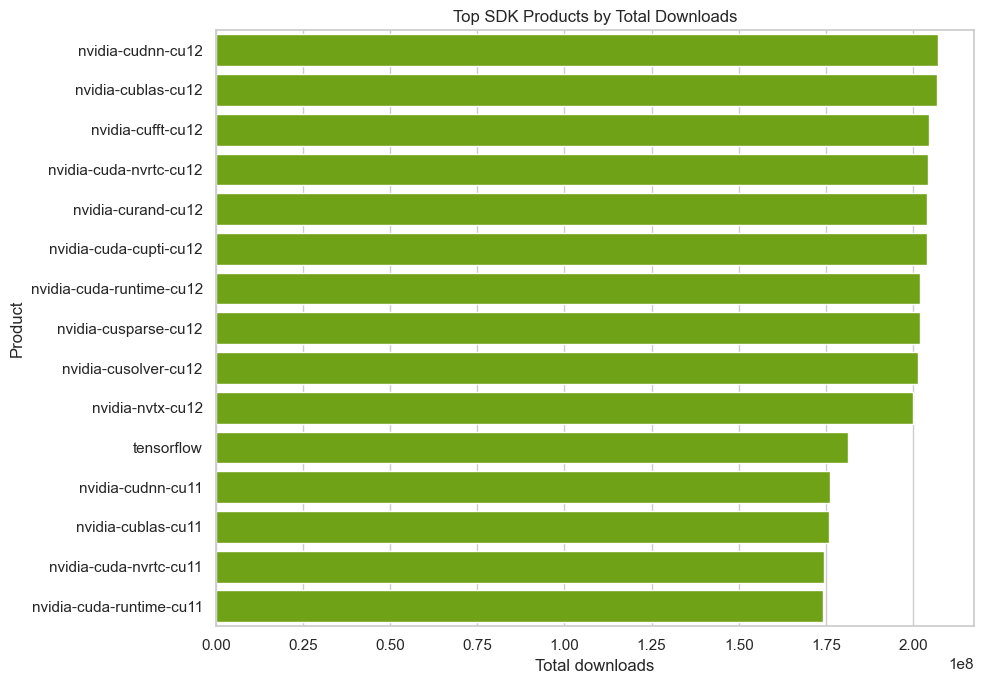

In [11]:
if sdk_table is None:
    display(Markdown('No SDK download table was found. Expected `sdk_download_final` or `sdk_download_clean`.'))
else:
    sdk_cols = set(con.execute(f"PRAGMA table_info('{sdk_table}')").fetchdf()['name'])
    developer_link_cols = sorted({'developer_id', 'dev_contact', 'contact_id'} & sdk_cols)
    print(f'Using SDK table: {sdk_table}')
    if developer_link_cols:
        print(f'Developer-link columns found: {developer_link_cols}')
    else:
        print('No developer-link column found in the SDK table. SDK product insights below are global demand signals, not developer-level attribution.')

    required_sdk_cols = {'sdk_name', 'product_name', 'product_release', 'download_date', 'download_count'}
    if not required_sdk_cols.issubset(sdk_cols):
        display(Markdown(f'SDK table `{sdk_table}` does not have the expected columns: {sorted(required_sdk_cols - sdk_cols)}'))
    else:
        con.execute(f"""
        CREATE OR REPLACE TABLE sdk_download_product_summary_v1 AS
        SELECT
            sdk_name,
            product_name,
            product_release,
            COUNT(*) AS rows,
            SUM(GREATEST(COALESCE(download_count, 0), 0)) AS total_downloads,
            MIN(download_date) AS first_download_date,
            MAX(download_date) AS last_download_date,
            COUNT(DISTINCT country) AS countries,
            COUNT(DISTINCT operating_system) AS operating_systems
        FROM {sdk_table}
        WHERE download_date IS NOT NULL
        GROUP BY 1, 2, 3
        ORDER BY total_downloads DESC
        """)

        con.execute(f"""
        CREATE OR REPLACE TABLE sdk_download_monthly_top_products_v1 AS
        WITH top_products AS (
            SELECT product_name
            FROM sdk_download_product_summary_v1
            GROUP BY product_name
            ORDER BY SUM(total_downloads) DESC
            LIMIT 25
        )
        SELECT
            DATE_TRUNC('month', download_date) AS download_month,
            product_name,
            SUM(GREATEST(COALESCE(download_count, 0), 0)) AS total_downloads,
            COUNT(*) AS rows
        FROM {sdk_table}
        WHERE download_date IS NOT NULL
          AND product_name IN (SELECT product_name FROM top_products)
        GROUP BY 1, 2
        ORDER BY download_month, total_downloads DESC
        """)

        sdk_top = con.execute("""
        SELECT *
        FROM sdk_download_product_summary_v1
        ORDER BY total_downloads DESC
        LIMIT 25
        """).fetchdf()
        display(sdk_top)

        if not sdk_top.empty:
            plt.figure(figsize=(10, 7))
            sns.barplot(data=sdk_top.head(15), y='product_name', x='total_downloads', color='#76b900')
            plt.title('Top SDK Products by Total Downloads')
            plt.xlabel('Total downloads')
            plt.ylabel('Product')
            plt.tight_layout()
            plt.show()


## 6. Report Tables and Exports

The notebook writes compact report tables back to DuckDB and exports CSV copies to `asset_impact_outputs/`.


In [12]:
report_tables = [
    'asset_first_touch_v1',
    'asset_pre_post_summary_v1',
    'asset_cluster_profile_v1',
    'asset_weekly_cluster_movement_summary_v1',
    'sdk_download_product_summary_v1',
    'sdk_download_monthly_top_products_v1',
]

current_tables = set(con.execute('SHOW TABLES').fetchdf().iloc[:, 0].astype(str))
exported = []
for table in report_tables:
    if table not in current_tables:
        continue
    df = con.execute(f'SELECT * FROM {table}').fetchdf()
    out_path = OUTPUT_DIR / f'{table}.csv'
    df.to_csv(out_path, index=False)
    exported.append({'table': table, 'rows': len(df), 'csv': str(out_path)})

exported_df = pd.DataFrame(exported)
display(exported_df)

summary = con.execute('SELECT * FROM asset_pre_post_summary_v1 ORDER BY avg_meaningful_count_delta DESC').fetchdf()
report_path = OUTPUT_DIR / 'asset_impact_report.md'
with report_path.open('w', encoding='utf-8') as f:
    f.write('# Asset Impact Report\n\n')
    f.write('Generated by `AssetImpact_Analysis.ipynb`.\n\n')
    f.write('## Pre/Post Summary\n\n')
    f.write(summary.to_markdown(index=False))
    f.write('\n\n')
    f.write('## Interpretation Notes\n\n')
    f.write('- Higher `avg_meaningful_count_delta` indicates stronger post-asset adoption signal.\n')
    f.write('- Higher `progressed_stage_rate` indicates more developers moved to a deeper journey stage after first touch.\n')
    f.write('- Higher `post_build_or_champion_rate` indicates stronger build/community adoption after first touch.\n')
    f.write('- Higher `shallow_no_lift_rate` indicates touchpoints that do not translate into meaningful post-window behavior.\n')

print(f'Wrote markdown report: {report_path}')


,table,rows,csv
0,asset_first_touch_v1,6089542,asset_impact_outputs/asset_first_touch_v1.csv
1,asset_pre_post_summary_v1,5,asset_impact_outputs/asset_pre_post_summary_v1...
2,asset_cluster_profile_v1,16,asset_impact_outputs/asset_cluster_profile_v1.csv
3,asset_weekly_cluster_movement_summary_v1,120,asset_impact_outputs/asset_weekly_cluster_move...
4,sdk_download_product_summary_v1,18710,asset_impact_outputs/sdk_download_product_summ...
5,sdk_download_monthly_top_products_v1,1314,asset_impact_outputs/sdk_download_monthly_top_...


Wrote markdown report: asset_impact_outputs/asset_impact_report.md


## 7. Analyst Checklist

Use this section after running the notebook:

1. Review `asset_pre_post_summary_v1` for the assets with the highest meaningful engagement delta and progression rate.
2. Review `asset_cluster_profile_v1` to identify which GMM cohorts over-index on each asset and which cohorts show actual post-touch lift.
3. Review weekly cluster movement, if available, to see whether assets precede changes in weekly engagement patterns.
4. Review SDK product tables for top products and monthly demand trends. Treat global SDK downloads separately from developer-linked attribution unless a developer key exists.
5. Summarize shallow engagement by identifying assets with high touch volume and high `shallow_no_lift_rate`.


In [ ]:
con.close()
print('DuckDB connection closed. Asset impact analysis notebook complete.')


## Key Asset Impact Insights

### 1. API Is The Strongest Per-Developer Adoption Signal

API touches are smaller in reach, with about **266k touched developers**, but they show the strongest per-developer lift:

- Average meaningful engagement delta: **+13.67**
- Average activity count delta: **+13.63**
- Stage progression rate: **52.2%**
- 31-90 day retention rate: **22.2%**

This makes API activity the clearest signal of deeper engagement. It appears to indicate repeated meaningful usage more than broad top-of-funnel activity.

### 2. Downloads Drive The Largest Total Impact, But Are Noisy

Downloads reach the largest population, with about **4.0M touched developers**. They generate the largest aggregate lift:

- Average meaningful engagement delta: **+2.21**
- Estimated total meaningful engagement delta: **~8.9M**
- Average build count delta: **+2.20**
- Stage progression rate: **28.0%**

However, downloads also have a high shallow no-lift rate of **72.1%**. This means downloads mix true adoption signals with a large amount of low-intent or one-off engagement.

### 3. Training Has Broad Reach But Weak Average Lift

Training reaches about **1.08M developers**, but average lift is modest:

- Average meaningful engagement delta: **+0.16**
- Stage progression rate: **15.4%**
- Shallow no-lift rate: **83.7%**

Training appears most useful when targeted to stronger cohorts. In `cluster_4`, training performs much better, with higher retention and post-build/champion behavior.

### 4. Webinars Look More Like Awareness Than Adoption

Webinars show some positive activity and score movement, but weaker meaningful adoption:

- Average activity count delta: **+1.22**
- Average activity score delta: **+8.55**
- Average meaningful engagement delta: **-0.27**
- Shallow no-lift rate: **70.6%**

This suggests webinars may support awareness or early nurture, but they are not strong standalone adoption drivers.

### 5. Forums Are A Deep-Engagement Marker

Forum activity has small reach, about **17.4k developers**, but strong mature-user characteristics:

- Post-build/champion rate: **48.2%**
- Stage progression rate: **43.0%**
- 31-90 day retention rate: **32.4%**

The negative pre/post deltas suggest forum users were already highly active before their first observed forum touch. Forums should be interpreted more as a marker of deep community engagement than as a broad acquisition driver.

### 6. Cluster 4 Is The Highest-Value Adoption Cohort

`cluster_4` shows the strongest asset response across multiple asset types. For example, downloads in `cluster_4` show:

- Average meaningful engagement delta: **+25.99**
- Average build count delta: **+24.73**
- Post-build/champion rate: **55.6%**
- 31-90 day retention rate: **53.2%**

This cluster should be prioritized for asset-to-adoption analysis and targeted conversion strategies.

### 7. Cluster 0 Looks Like Shallow Engagement

Downloads and webinars in `cluster_0` show almost no meaningful lift:

- Download shallow no-lift rate: **100%**
- Webinar shallow no-lift rate: **99.9%**

This cluster likely represents low-intent, low-depth, or one-off engagement behavior.

### 8. SDK Developer-Level Attribution Is Not Available Yet

The SDK product tables produce useful demand insights, but the SDK download table does not appear to contain a developer identifier. As a result, SDK downloads can be analyzed as product-level demand, but not reliably tied to developer-level cohort movement or pre/post engagement.

Developer-level SDK impact would require a developer key or a reliable mapping between SDK download records and developer profiles.

### 9. SDK Demand Is Dominated By PyTorch, TensorFlow, And CUDA Packages

Top SDK/product demand is concentrated in major AI and CUDA ecosystem packages:

- `torch`: about **1.51B** downloads
- `tensorflow`: about **1.23B** downloads
- `nvidia-nccl-cu12`: about **709M** downloads
- `triton`: about **673M** downloads
- CUDA/cu12 packages such as `cublas`, `cusparse`, `cudnn`, `cufft`, `nvrtc`, and `cusolver` are also very large.

These are strong product-demand signals, but they should not be interpreted as developer-level adoption without a developer-linked SDK table.

## Overall Takeaway

API activity is the strongest per-developer meaningful adoption signal. Downloads create the largest aggregate lift, but they require filtering because much of the engagement is shallow. Training and webinars appear more useful as nurture assets unless targeted to high-potential cohorts. Forums are a strong signal of mature community engagement. SDK downloads show major product demand, but developer-level impact cannot be attributed without a developer identifier.